In [7]:
from algorithms.genetic import genetic_algorithm
from algorithms.linear_programing import linear_programing
from algorithms.brute_force import brute_force
from algorithms.vns import VNS
from utilities.graph import draw_graph, read_graph, generate_graph, save_graph
from testing.evaluation import evaluate_algorithms, evaluate_on_graph, save_evaluation
from utilities.diagrams import plot_results, save_result_plots

import glob

In [3]:
eval_results_small = evaluate_algorithms("graphs/small")

Progress: 125/125 (100%)


In [4]:
eval_results_small

,Algorithm,Success,Success %,Average Gap %,Average Time (s)
0,Linear Programming,25,100.0,0.0,0.000031
1,Brute force,25,100.0,0.0,0.007389
2,VNS,25,100.0,0.0,0.037861
3,VNS (no pruning),25,100.0,0.0,0.022280
4,Genetic Algorithm,25,100.0,0.0,0.707669


In [5]:
save_evaluation(eval_results_small, "./results/eval_results_small")

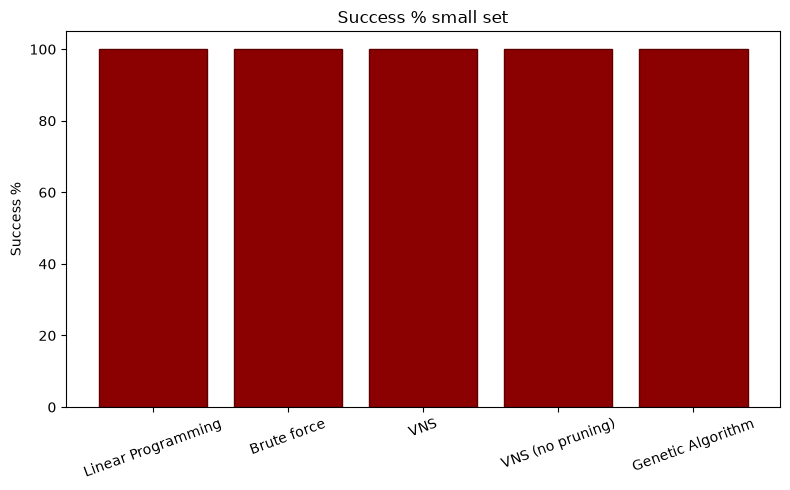

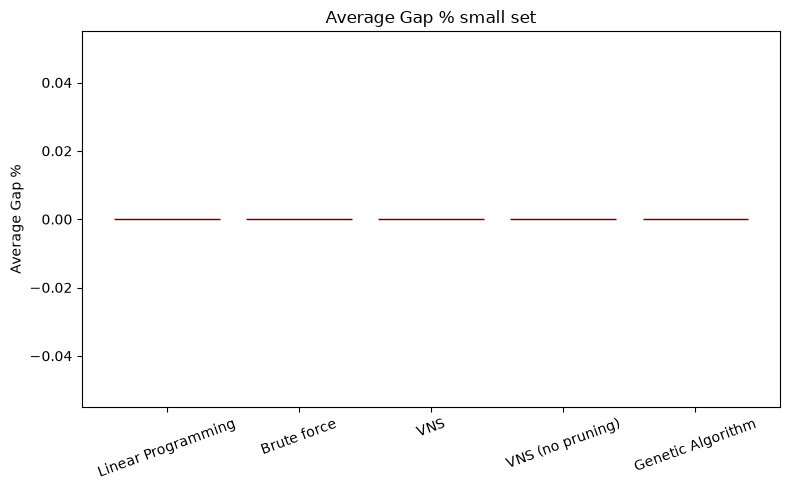

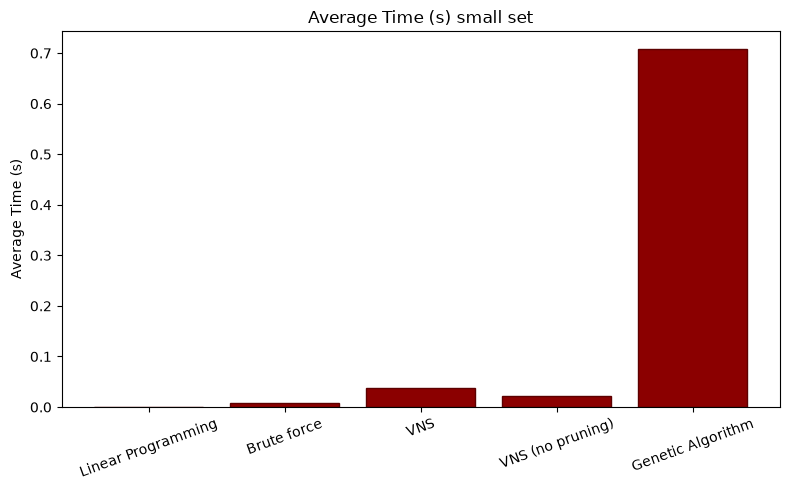

In [6]:
plot_results(eval_results_small, "small set")

In [7]:
save_result_plots(eval_results_small, output_folder="results/plots/small")

In [8]:
eval_results_medium = evaluate_algorithms("graphs/medium")

Progress: 125/125 (100%)


In [9]:
eval_results_medium

,Algorithm,Success,Success %,Average Gap %,Average Time (s)
0,Linear Programming,25,100.0,0.000000,0.016150
1,Brute force,25,100.0,0.000000,0.012185
2,VNS,25,100.0,0.000000,0.108731
3,VNS (no pruning),19,76.0,8.133333,0.044837
4,Genetic Algorithm,25,100.0,0.000000,0.973487


In [ ]:
save_evaluation(eval_results_medium, "./results/eval_results_medium")

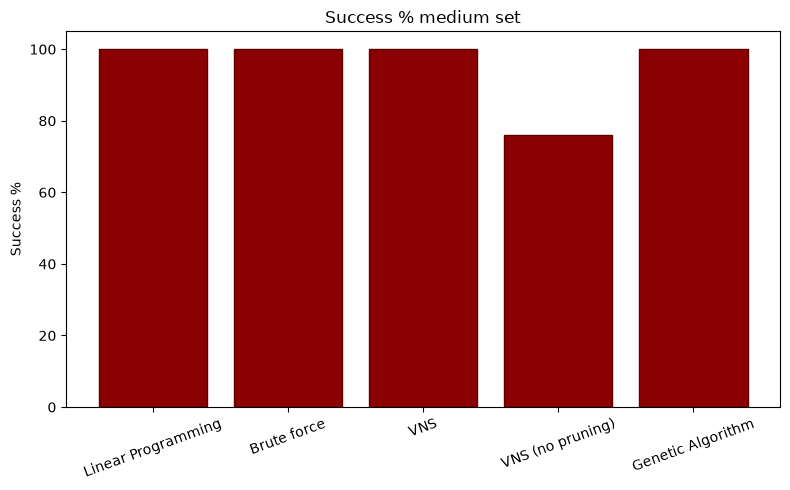

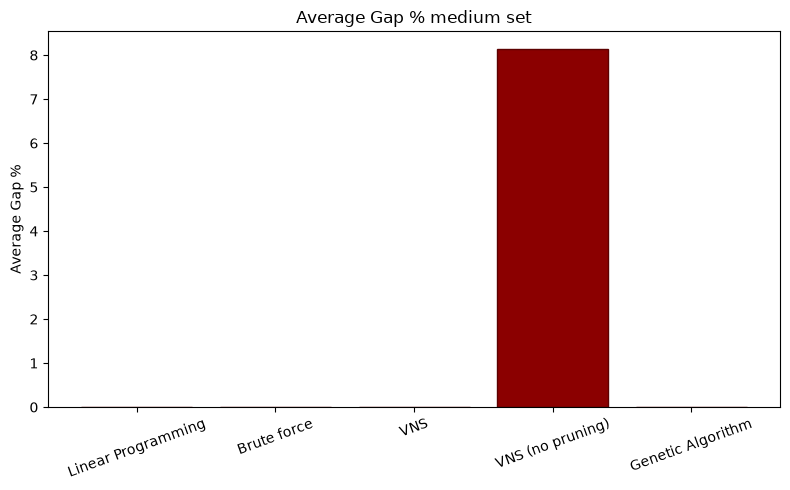

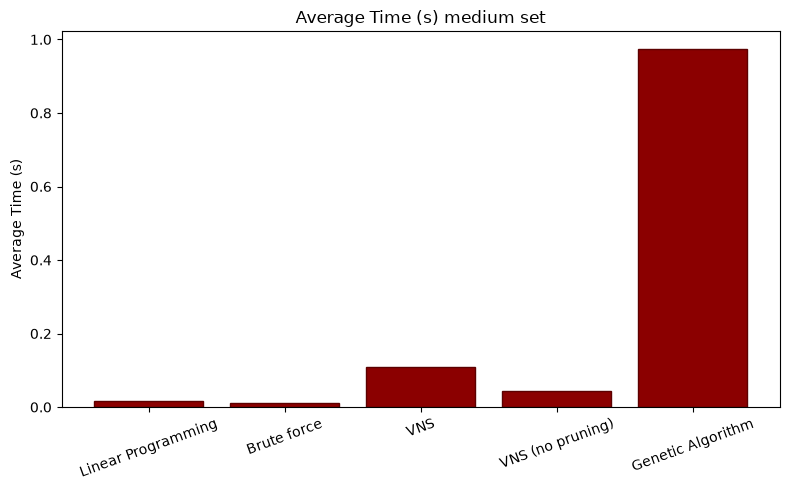

In [12]:
plot_results(eval_results_medium, "medium set")

In [13]:
save_result_plots(eval_results_medium, output_folder="results/plots/medium")

In [2]:
eval_results_large = evaluate_algorithms("graphs/large", do_brute_force=False)

Progress: 100/100 (100%)


In [3]:
eval_results_large

,Algorithm,Success,Success %,Average Gap %,Average Time (s)
0,Linear Programming,25,100.0,0.000000,0.135235
1,VNS,11,44.0,5.989755,12.199603
2,VNS (no pruning),0,0.0,27.652525,2.346427
3,Genetic Algorithm,3,12.0,10.388023,17.464035


In [4]:
save_evaluation(eval_results_large, "./results/eval_results_large")

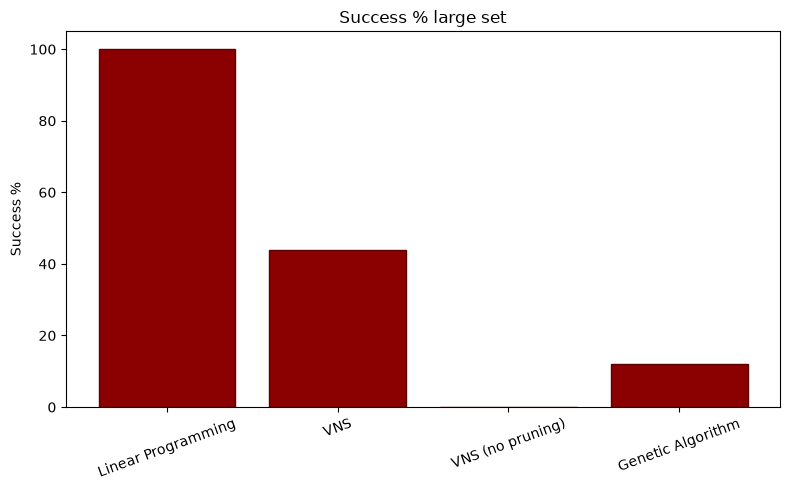

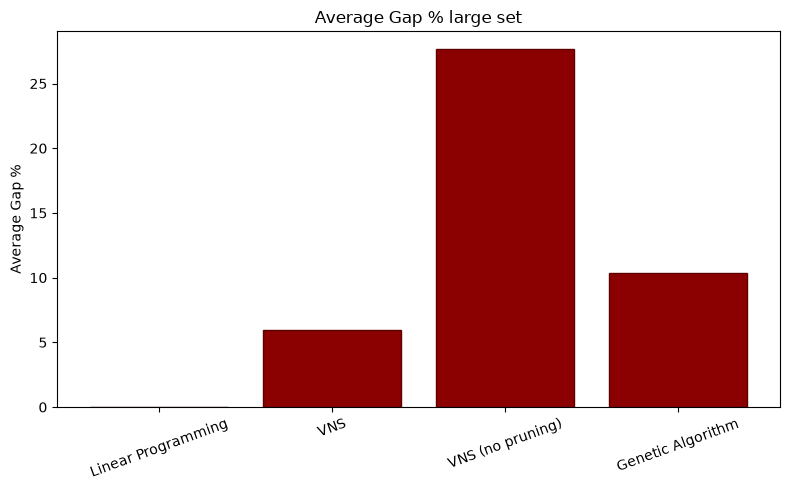

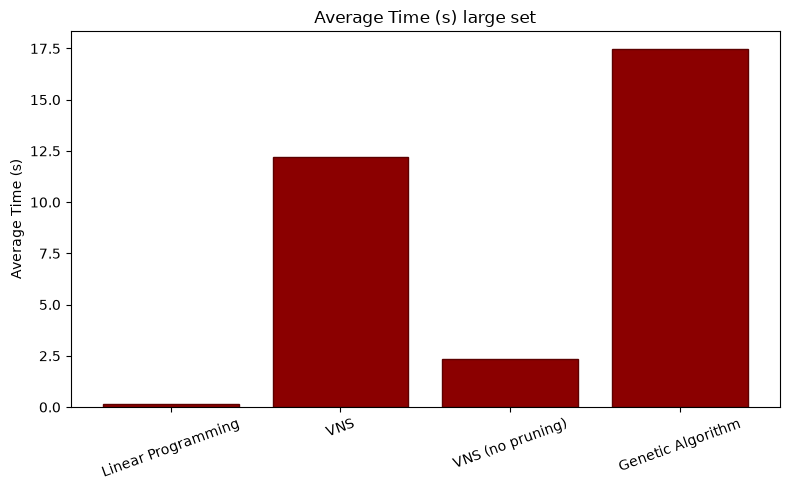

In [5]:
plot_results(eval_results_large, "large set")

In [6]:
save_result_plots(eval_results_large, output_folder="results/plots/large")

In [41]:
test_graph = generate_graph(210, average_degree=17, seed=12345)

In [42]:
eval_big_graph_1 = evaluate_on_graph(test_graph, do_brute_force=False)

Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!


In [43]:
eval_big_graph_1

,Algorithm,Success,Success %,Average Gap %,Average Time (s)
0,Linear Programming,1,100.0,0.000000,598.674361
1,VNS,0,0.0,17.647059,97.994446
2,VNS (no pruning),0,0.0,35.294118,19.559223
3,Genetic Algorithm,0,0.0,11.764706,41.590272


In [45]:
save_evaluation(eval_big_graph_1, "results/big_graph_210")

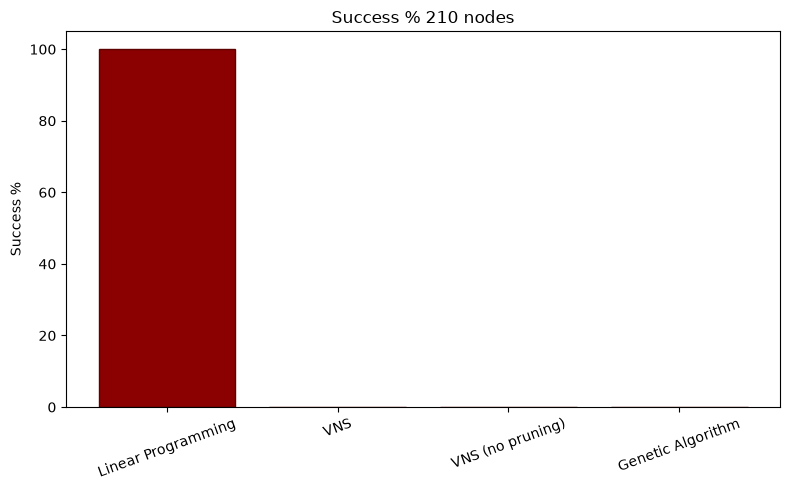

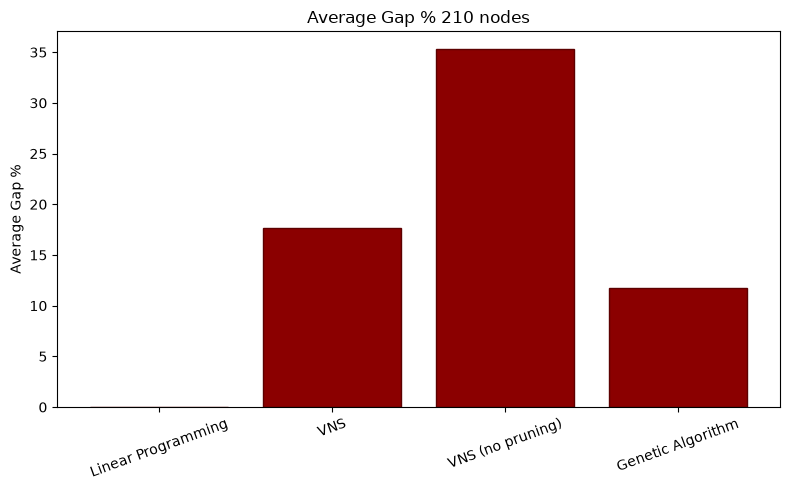

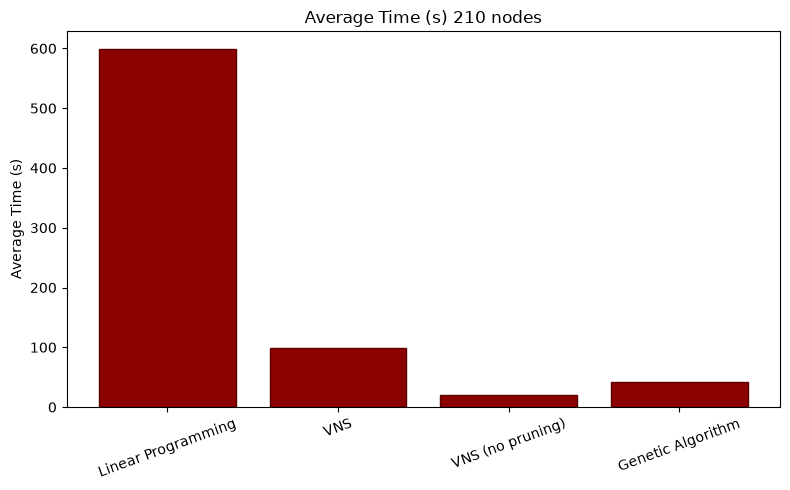

In [46]:
plot_results(eval_big_graph_1, "210 nodes")

In [47]:
save_result_plots(eval_big_graph_1, "results/plots/nodes_195", "195 nodes")

In [8]:
graph_extreme = generate_graph(1000, 200, 12345)

In [14]:
import time

start = time.perf_counter()
results = VNS(graph_extreme, 1000, 50)
elapsed = time.perf_counter() - start

In [17]:
import pandas as pd

df = pd.DataFrame([results.fitness, elapsed], index=["Result", "Time"])
df.to_csv("results/big_graph_1000_VNS.csv")


In [13]:
import time
start = time.perf_counter()
results = VNS(graph_extreme, 10000, 50, do_prune=False)
elapsed = time.perf_counter() - start

In [18]:
import pandas as pd

df = pd.DataFrame([results.fitness, elapsed], index=["Result", "Time"])
df.to_csv("results/big_graph_1000_VNSnp.csv")

In [19]:
df

,0
Result,18.000000
Time,533.467165


In [26]:
start = time.perf_counter()
result = genetic_algorithm(200, graph_extreme, 10, 200, 100, 50, 0.05)
elapsed = time.perf_counter() - start

In [28]:
result.fitness

16

In [ ]:
df = pd.DataFrame([result.fitness, elapsed], index=["Result", "Time"])
df.to_csv("results/big_graph_1000_GA200.csv")

In [31]:
start = time.perf_counter()
result = VNS(graph_extreme, 200, 50)
elapsed = time.perf_counter() - start

In [35]:
result.fitness

16

In [37]:
df = pd.DataFrame([result.fitness, elapsed], index=["Result", "Time"])
df.to_csv("results/big_graph_1000_VNS200.csv")

In [38]:
start = time.perf_counter()
result = VNS(graph_extreme, 1000, 50, do_prune=False)
elapsed = time.perf_counter() - start

In [39]:
result.fitness

19

In [40]:
df = pd.DataFrame([result.fitness, elapsed], index=["Result", "Time"])
df.to_csv("results/big_graph_1000_VNS200np.csv")

Finished linear!
Finished brute force!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished brute force!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished brute force!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!


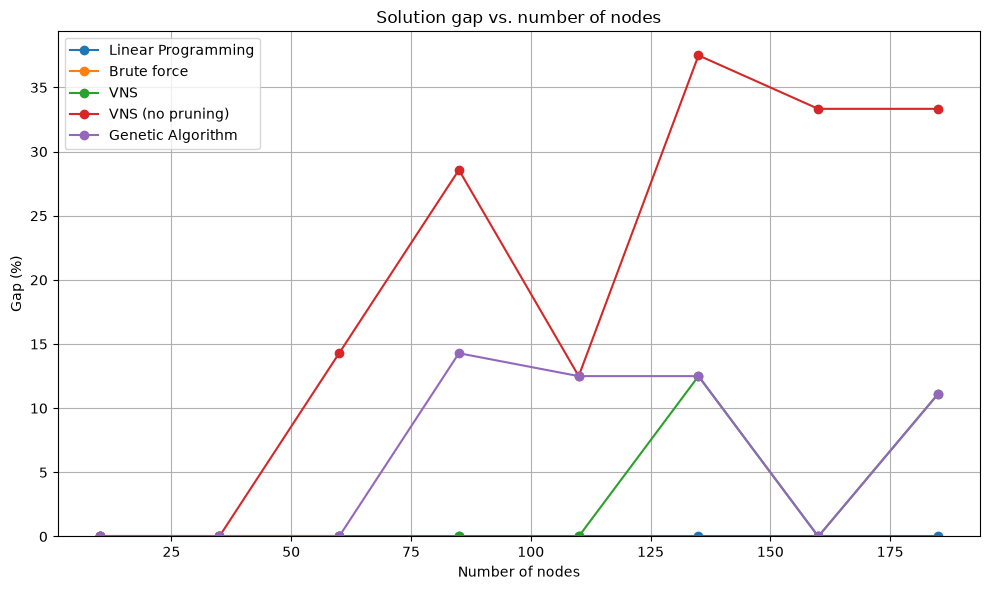

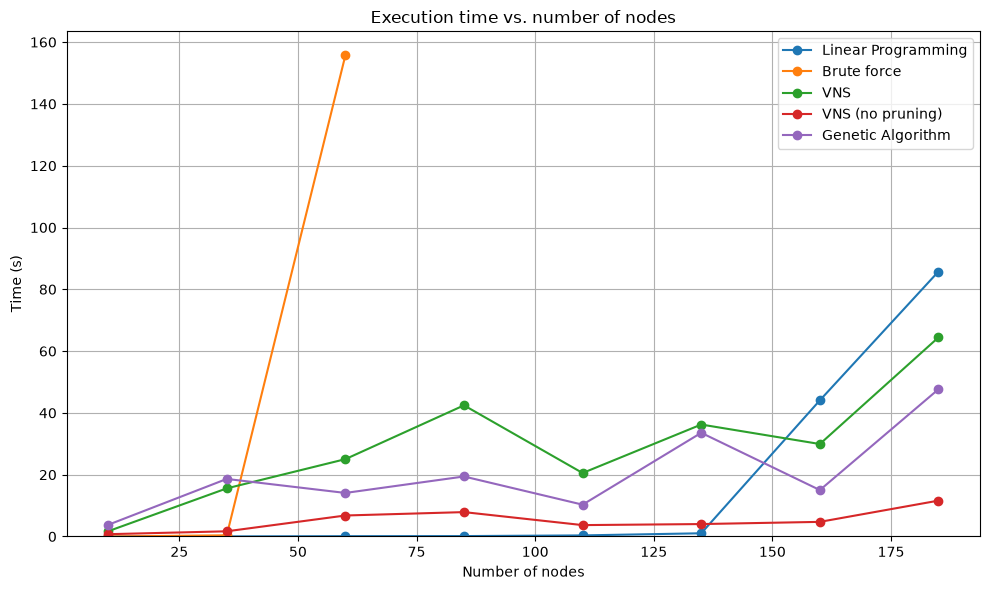

In [29]:
import matplotlib.pyplot as plt

results = []

for i in range(10, 186, 25):
    graph = generate_graph(i, int(i * 0.2))

    do_brute_force = i <= 60

    df = evaluate_on_graph(
        graph,
        do_brute_force=do_brute_force
    )

    for _, row in df.iterrows():
        results.append({
            "Nodes": i,
            "Algorithm": row["Algorithm"],
            "Gap %": row["Average Gap %"],
            "Time (s)": row["Average Time (s)"]
        })

results = pd.DataFrame(results)

# ---------------- GAP ----------------

plt.figure(figsize=(10, 6))

for algorithm in results["Algorithm"].unique():
    data = results[results["Algorithm"] == algorithm]

    plt.plot(
        data["Nodes"],
        data["Gap %"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of nodes")
plt.ylabel("Gap (%)")
plt.title("Solution gap vs. number of nodes")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.savefig(
    "results/plots/gap_vs_nodes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()
plt.close()

# ---------------- TIME ----------------

plt.figure(figsize=(10, 6))

for algorithm in results["Algorithm"].unique():
    data = results[results["Algorithm"] == algorithm]

    plt.plot(
        data["Nodes"],
        data["Time (s)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of nodes")
plt.ylabel("Time (s)")
plt.title("Execution time vs. number of nodes")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.savefig(
    "results/plots/time_vs_nodes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()
plt.close()



Finished linear!
Finished brute force!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished brute force!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished brute force!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!
Finished linear!
Finished VNS(no pruning)!
Finished VNS!
Finished genetic!


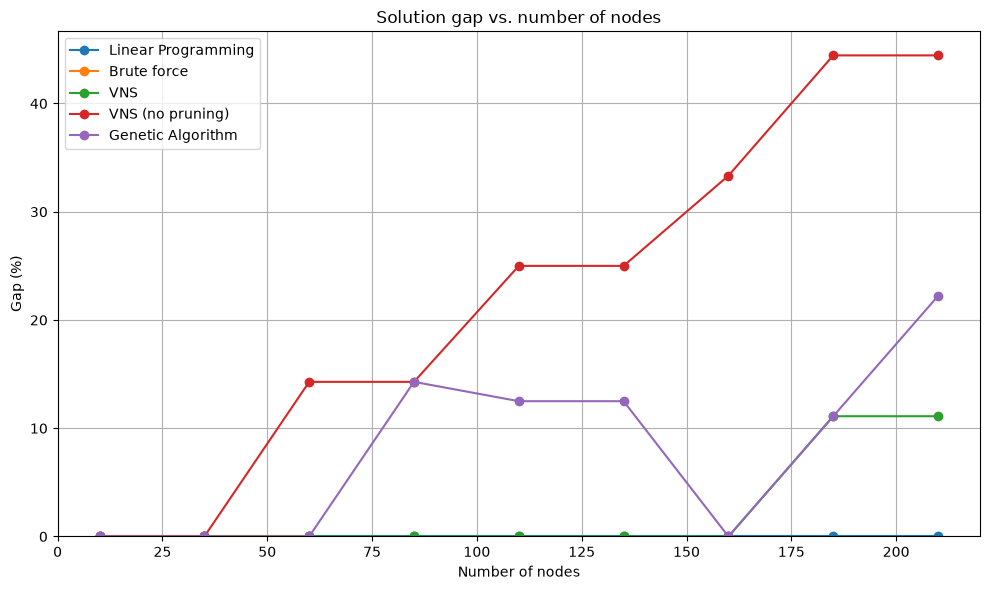

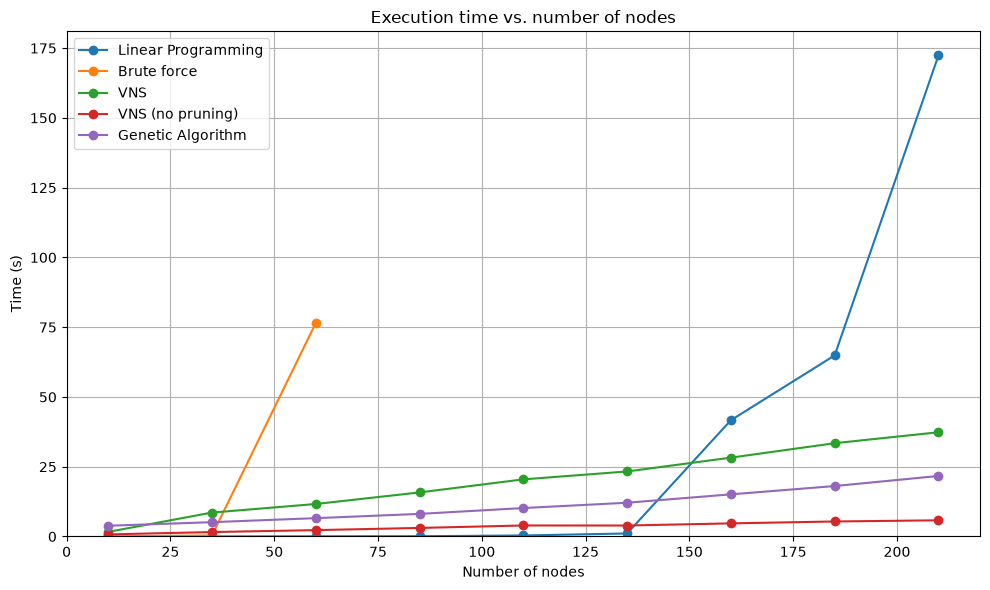

In [48]:
results = []

for i in range(10, 211, 25):
    graph = generate_graph(i, int(i * 0.2))

    do_brute_force = i <= 60

    df = evaluate_on_graph(
        graph,
        do_brute_force=do_brute_force
    )

    for _, row in df.iterrows():
        results.append({
            "Nodes": i,
            "Algorithm": row["Algorithm"],
            "Gap %": row["Average Gap %"],
            "Time (s)": row["Average Time (s)"]
        })

results = pd.DataFrame(results)

# ---------------- GAP ----------------

plt.figure(figsize=(10, 6))

for algorithm in results["Algorithm"].unique():
    data = results[results["Algorithm"] == algorithm]

    plt.plot(
        data["Nodes"],
        data["Gap %"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of nodes")
plt.ylabel("Gap (%)")
plt.title("Solution gap vs. number of nodes")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.savefig(
    "results/plots/gap_vs_nodes_1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()
plt.close()

# ---------------- TIME ----------------

plt.figure(figsize=(10, 6))

for algorithm in results["Algorithm"].unique():
    data = results[results["Algorithm"] == algorithm]

    plt.plot(
        data["Nodes"],
        data["Time (s)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of nodes")
plt.ylabel("Time (s)")
plt.title("Execution time vs. number of nodes")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.savefig(
    "results/plots/time_vs_nodes_1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()
plt.close()